100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6864/6864 [00:07<00:00, 947.34it/s]


<Axes: xlabel='date'>

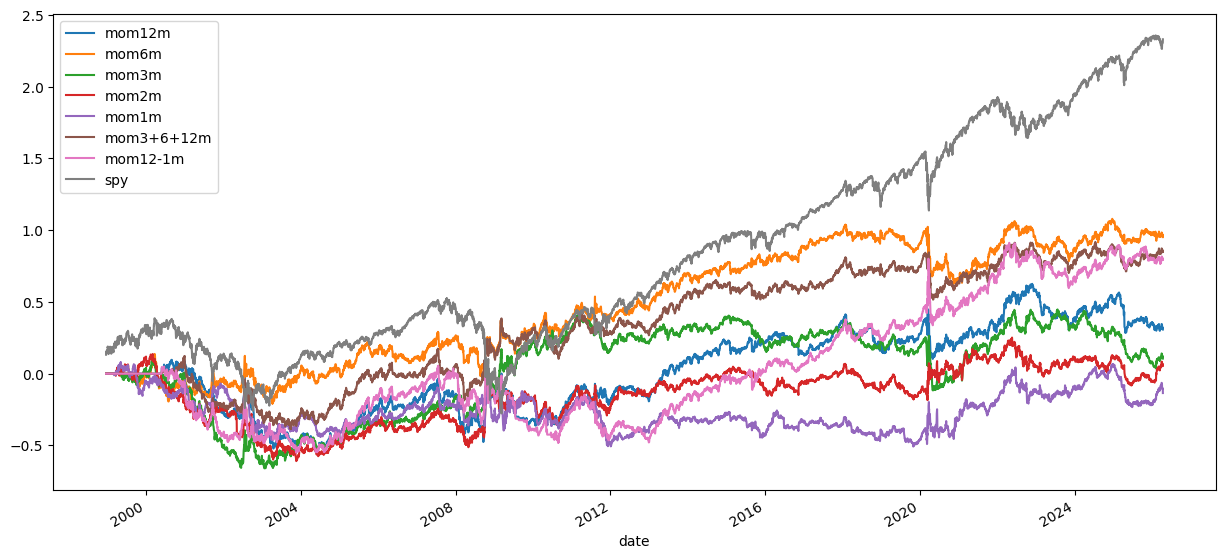

In [100]:
# derive spx membership

import polars as pl
import numpy as np
import pandas as pd
from typing import Callable, Literal
from tqdm import tqdm

sector_etfs = [
    "XLB",
    "XLC",
    "XLE",
    "XLF",
    "XLI",
    "XLK",
    "XLP",
    "XLRE",
    "XLU",
    "XLV",
    "XLY",
]


def zscore(window: int) -> Callable[[pl.Expr], pl.Expr]:
    def _zscore(val: pl.Expr) -> pl.Expr:
        return (val - val.rolling_mean(window)) / val.rolling_std(window)

    return _zscore


# yang-zhang variance estimation parameters
yz_k = 0.34
yz_win = 25

max_long = 2
max_short = 1
rebalance_period = 1

signals = {
    'mom12m': pl.col('mom12m'),
    'mom6m': pl.col('mom6m'),
    'mom3m': pl.col('mom3m'),
    'mom2m': pl.col('mom2m'),
    'mom1m': pl.col('mom1m'),
    'mom3+6+12m': pl.col('mom12m') + pl.col('mom6m') + pl.col('mom3m'),
    'mom12-1m': pl.col('mom12m') - pl.col('mom1m'),
}

perf = None

for signal, expr in signals.items(): 
    df = (
        # uv run yf.py SPY XLB XLC XLE XLF XLI XLK XLP XLRE XLU XLV XLY --output yf.parquet
        pl.read_parquet("yf.parquet")
        .filter(pl.col("symbol").is_in(sector_etfs))
        .select(
            date=pl.col("ts").dt.date(),
            symbol=pl.col("symbol"),
            open=pl.col("open"),
            high=pl.col("high"),
            low=pl.col("low"),
            close=pl.col("close"),
            vol=pl.col("volume"),
        )
        .sort(["symbol", "date"])
        # yz-variance estimation
        .with_columns(
            o=pl.col("open").log() - pl.col("close").shift(1).over('symbol').log(),
            u=pl.col("high").log() - pl.col("open").log(),
            d=pl.col("low").log() - pl.col("open").log(),
            c=pl.col("close").log() - pl.col("open").log(),
        )
        .with_columns(
            rs=pl.col("u") * (pl.col("u") - pl.col("c"))
            + pl.col("d") * (pl.col("d") - pl.col("c"))
        )
        .with_columns(
            var=(
                pl.col("o").rolling_var(yz_win)
                + yz_k * pl.col("c").rolling_var(yz_win)
                + ((1 - yz_k) * pl.col("rs").rolling_mean(yz_win))
            ).over("symbol")
        )
        .select(["date", "symbol", "close", "vol", "var"])
        .with_columns(
            **{
                f"mom{n}m": pl.col("close").pct_change(21 * n).over("symbol")
                for n in [1, 2, 3, 6, 12]
            },
            sma50d=pl.col("close").rolling_mean(50).over("symbol"),
        )
        .with_columns(score=expr)
        .with_columns(
            long_rank=pl.when((pl.col("sma50d") < pl.col("close")) & (pl.col('score') > 0))
            .then(pl.col("score").rank(descending=True).over("date") / pl.len().over("date"))
            .otherwise(None),
            short_rank=pl.when((pl.col("sma50d") > pl.col("close")) & (pl.col('score') < 0))
            .then(pl.col("score").rank(descending=True).over("date") / pl.len().over("date"))
            .otherwise(None),
        )
    )
    
    
    portfolio = []
    days_since_rebalance = rebalance_period
    
    perf_frag = []
    
    for day in tqdm(df["date"].unique().sort().to_list()):
        df_now = df.filter(pl.col("date") == day)
    
        # compute todays eod portfolio return
        ret_long = 0.0
        ret_short = 0.0
    
        for i in range(len(portfolio)):
            sym = portfolio[i]['symbol']
            w = portfolio[i]['weight']
            close = portfolio[i]['close']
            
            row = df_now.filter(pl.col("symbol") == sym)
            if len(row) == 0:
                print(f"error: {sym} not found on {day}")
                continue
    
            ret = row["close"][0] / close
            if w > 0:
                ret_long += (ret - 1) * w
            elif w < 0:
                ret_short += (1 - ret) * abs(w)
                
            portfolio[i]['close'] = row["close"][0]
    
        perf_frag.append(
            pl.DataFrame(
                {
                    "date": [day],
                    signal: [ret_long + ret_short],
                    #"ret_long": [ret_long],
                    #"ret_short": [ret_short],
                }
            )
        )
    
        # rebalance portfolio
        long_bkt = (
            df_now.filter(pl.col("long_rank").is_null().not_())
            .sort("long_rank")["symbol"]
            .to_list()
        )
        short_bkt = (
            df_now.filter(pl.col("short_rank").is_null().not_())
            .sort("short_rank", descending=False)["symbol"]
            .to_list()
        )
    
        bkt_len = len(long_bkt[:max_long]) + len(short_bkt[:max_short])
        yd_folio = portfolio.copy()
        portfolio = []
    
        if days_since_rebalance < rebalance_period:
            for pos in yd_folio:
                row = df_now.filter(pl.col("symbol") == pos["symbol"])
                if len(row) == 0:
                    continue
    
                if pos["weight"] > 0 and pos["symbol"] in long_bkt:
                    portfolio.append(pos)
                elif pos["weight"] < 0 and pos["symbol"] in short_bkt:
                    portfolio.append(pos)
    
            for i in range(len(portfolio)):
                sign_w = (
                    1
                    if portfolio[i]["weight"] > 0
                    else -1 if portfolio[i]["weight"] < 0 else 0
                )
                portfolio[i]["weight"] = sign_w * 1.0 / len(portfolio)
    
            days_since_rebalance += 1
    
        elif bkt_len > 0:
            w = 1.0 / bkt_len
            close = dict(df_now[['symbol','close']].iter_rows(named=False))
            portfolio = [
                {"symbol": s, "weight": w, 'close': close[s]} for s in long_bkt[:max_long]
            ] + [
                {"symbol": s, "weight": -w, 'close': close[s]} for s in short_bkt[:max_short]
            ]
            days_since_rebalance = 0
    
    if perf is None:
        perf = pl.concat(perf_frag)
    else:
        perf = perf.join(pl.concat(perf_frag), on='date', how='inner')

(
    perf
        .join(
            pl.read_parquet('yf.parquet')
            .filter(pl.col('symbol') == 'SPY')
            .sort('ts')
            .select(
                date=pl.col('ts').dt.date(),
                spy=(pl.col('close').pct_change() + 1).log().cum_sum() - 1,
            ),
            on='date'
        )
        .with_columns(
            [(pl.col(c) + 1).log().cum_sum() for c in signals.keys()]
        )
        .to_pandas()
        .plot(x='date',y=[*signals.keys(),'spy'],figsize=(15, 7))
)